# Importing Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv("NSE Stock data.csv")
df.head()

,Exchange,Symbol,Company,Price,Change %,Volume,Relative Volume,Market Cap,P/E,P/B,ROE,ROA,EPS TTM,EPS Growth YoY,Dividend Yield,RSI,SMA20,SMA50,SMA200,Sector
0,NSE,RELIANCE,Reliance Industries Limited,1388.20,-3.274805,15261787,0.665795,1.942867e+13,23.256944,NaN,9.269837,3.913270,59.6897,15.972815,0.417915,48.733226,1385.135,1383.666,1432.79250,Energy Minerals
1,NSE,HDFCBANK,HDFC Bank Limited,763.65,-2.202728,41123422,1.200326,1.202697e+13,15.499290,NaN,13.765023,1.633562,49.4950,6.645022,1.664107,40.777683,789.920,810.397,933.36800,Finance
2,NSE,BHARTIARTL,Bharti Airtel Limited,1759.80,-4.071954,15803791,1.925461,1.117440e+13,35.265614,8.589912,26.624249,5.899798,49.9013,23.289495,0.871982,37.047871,1839.825,1845.240,1960.73700,Communications
3,NSE,SBIN,State Bank of India,973.60,-4.483469,46927396,2.871032,9.411077e+12,10.695469,NaN,15.380589,1.065491,91.0292,4.742990,1.701731,31.681562,1076.760,1086.811,971.94975,Finance
4,NSE,ICICIBANK,ICICI Bank Limited,1266.40,0.126502,18980488,1.092127,9.066754e+12,16.935009,NaN,16.014888,1.948894,75.8900,7.349986,0.948767,43.085922,1313.105,1301.256,1370.93300,Finance


# Data Cleaning Phase 

In [3]:
df.isnull().sum() # Checking for Null Values 
df.drop(columns=['P/B','ROE','ROA','Dividend Yield'],inplace=True) # Dropping Columns having high null values 

In [4]:
cols= ['Relative Volume','P/E','EPS TTM','EPS Growth YoY','RSI','SMA20','SMA50','SMA200' ] # Defining Columns 

# Replacing Null Values with Median 
for i in cols: 
    df[i]=df[i].fillna(df[i].median())

In [5]:
df.isnull().sum() # Checking for Null Values ( Found : 0 )

Exchange           0
Symbol             0
Company            0
Price              0
Change %           0
Volume             0
Relative Volume    0
Market Cap         0
P/E                0
EPS TTM            0
EPS Growth YoY     0
RSI                0
SMA20              0
SMA50              0
SMA200             0
Sector             0
dtype: int64

In [6]:
# Standardizing Market Cap Column 
df["Market Cap (Cr)"] = df["Market Cap"] / 10000000
pd.options.display.float_format = '{:,.2f}'.format
df.head()

,Exchange,Symbol,Company,Price,Change %,Volume,Relative Volume,Market Cap,P/E,EPS TTM,EPS Growth YoY,RSI,SMA20,SMA50,SMA200,Sector,Market Cap (Cr)
0,NSE,RELIANCE,Reliance Industries Limited,"1,388.20",-3.27,15261787,0.67,"19,428,665,671,263.00",23.26,59.69,15.97,48.73,"1,385.14","1,383.67","1,432.79",Energy Minerals,"1,942,866.57"
1,NSE,HDFCBANK,HDFC Bank Limited,763.65,-2.20,41123422,1.20,"12,026,966,313,715.00",15.50,49.49,6.65,40.78,789.92,810.40,933.37,Finance,"1,202,696.63"
2,NSE,BHARTIARTL,Bharti Airtel Limited,"1,759.80",-4.07,15803791,1.93,"11,174,404,964,695.00",35.27,49.90,23.29,37.05,"1,839.82","1,845.24","1,960.74",Communications,"1,117,440.50"
3,NSE,SBIN,State Bank of India,973.60,-4.48,46927396,2.87,"9,411,076,636,491.00",10.70,91.03,4.74,31.68,"1,076.76","1,086.81",971.95,Finance,"941,107.66"
4,NSE,ICICIBANK,ICICI Bank Limited,"1,266.40",0.13,18980488,1.09,"9,066,754,351,979.00",16.94,75.89,7.35,43.09,"1,313.10","1,301.26","1,370.93",Finance,"906,675.44"


In [7]:
df.drop('Market Cap',inplace = True,axis=1) # Dropping Market Cap Column

In [8]:
csv='Cleaned_Stocks.csv' # Storing our Clean Dataset
df.to_csv(csv,index=False)

# Distribution Analysis (EDA)

In [9]:
df.describe() # Summary Statistics for our Dataset

,Price,Change %,Volume,Relative Volume,P/E,EPS TTM,EPS Growth YoY,RSI,SMA20,SMA50,SMA200,Market Cap (Cr)
count,"2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00","2,388.00"
mean,948.71,-1.17,"2,491,402.02",1.41,55.70,33.11,48.20,57.22,845.25,806.77,844.37,"19,802.33"
std,"4,306.22",2.90,"38,888,861.48",3.82,343.58,197.75,"1,564.75",11.11,"3,533.09","3,483.56","3,729.67","78,906.06"
min,0.26,-15.35,1.00,0.00,0.07,-232.36,"-39,922.19",7.86,0.26,0.21,0.40,128.23
25%,107.98,-2.85,"26,496.50",0.51,17.61,3.17,-12.64,49.75,111.84,108.50,132.46,484.17
50%,269.43,-1.50,"130,035.00",0.80,26.83,10.04,8.79,56.54,260.00,244.83,274.43,"1,913.52"
75%,683.79,0.02,"668,256.75",1.29,40.98,24.10,29.70,64.17,617.98,577.16,605.24,"9,273.59"
max,"128,910.00",20.00,"1,860,835,451.00",115.65,"14,747.40","6,510.06","52,927.94",100.00,"133,490.25","134,007.30","145,747.08","1,942,866.57"


Text(0, 0.5, 'Stocks Bins')

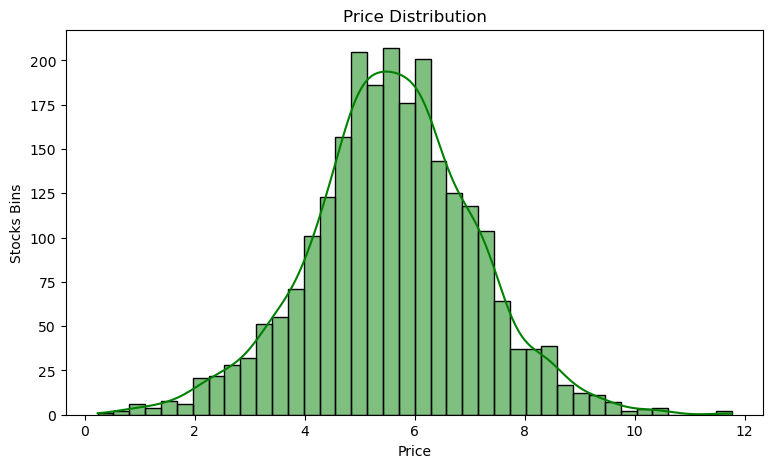

In [10]:
# Price Distribution Analysis Across Stocks 
plt.figure(figsize=(9,5))
sns.histplot(np.log1p(df['Price']),bins=40,kde=True,color='green') # Used Log to Compress Outliers 
plt.title('Price Distribution')
plt.ylabel('Stocks Bins')

# Insight Found :- Most of the Stocks Listed in NSE have a moderate Price with rare number of penny and over expensive Stocks

Text(0, 0.5, 'Stocks Bins')

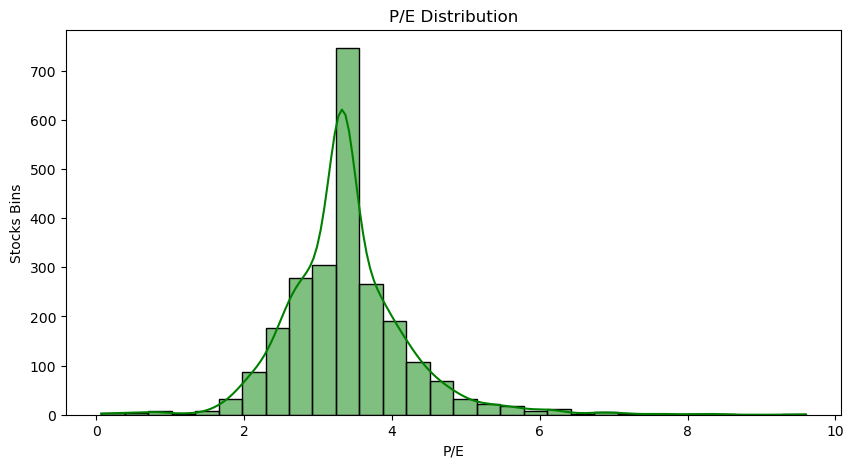

In [11]:
# P/E Distribution Analysis Across Stocks 
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['P/E']),bins=30,kde=True,color='green')
plt.title('P/E Distribution')
plt.ylabel('Stocks Bins')

# Insight Found :- Most Stocks have a moderate Price to Earning Distribution having stable earning valuation

Text(0, 0.5, 'Stocks Bins')

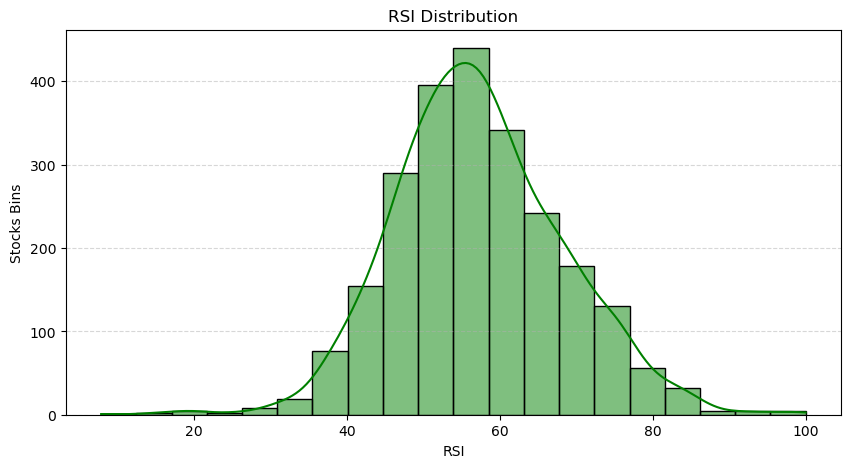

In [12]:
# RSI Distribution Analysis Across Stocks 
plt.figure(figsize=(10,5))
sns.histplot(x='RSI',bins=20,data=df,kde=True,color='Green')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('RSI Distribution')
plt.ylabel('Stocks Bins')

# Insight Found :- Most stocks have a moderate RSI meaning very few Stocks are oversold and overought 

Text(0, 0.5, 'Sector')

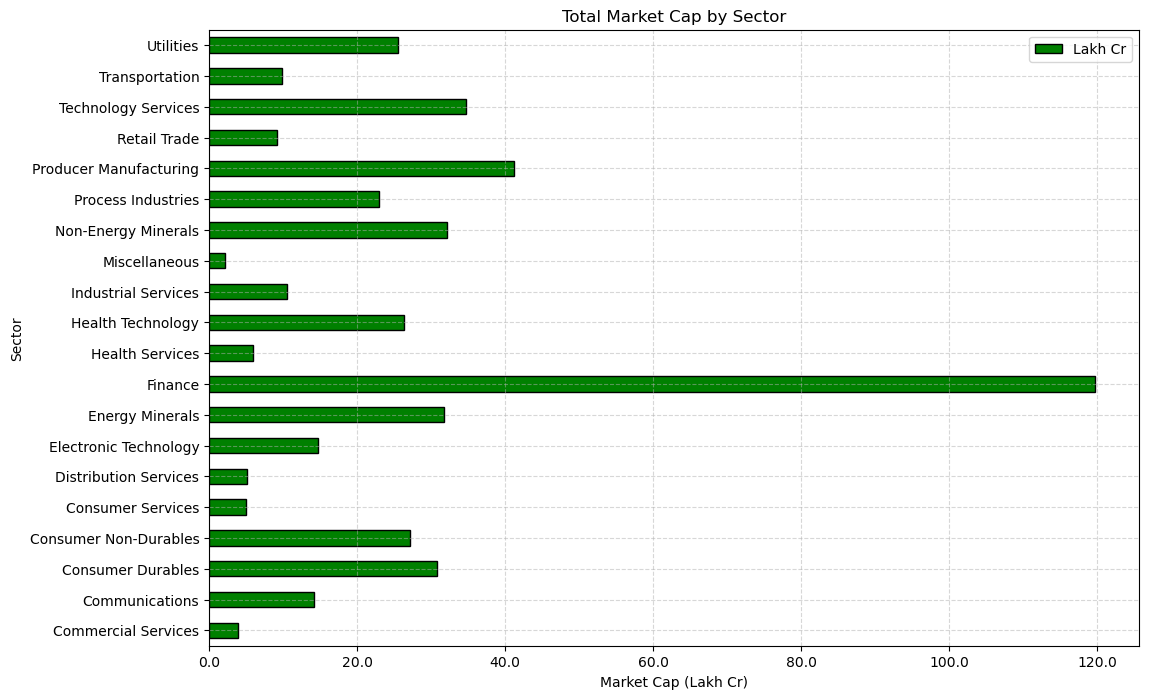

In [13]:
# Analyzing Total Market Cap by each Sector

# Defining an Unit (Lakh Crore)
m_sec = (
    df.groupby('Sector')['Market Cap (Cr)'].sum() / 100000
)

plt.figure(figsize=(12,8))

ax = m_sec.plot(kind='barh',color='green',edgecolor='black')

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.1f}')
)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.title("Total Market Cap by Sector")
plt.legend(['Lakh Cr'])
plt.xlabel("Market Cap (Lakh Cr)")
plt.ylabel("Sector")

# Insight Found: Finance Industry has the Highest Market cap followed by Producer Manufacturing Industry 

# Sector Analysis (EDA)

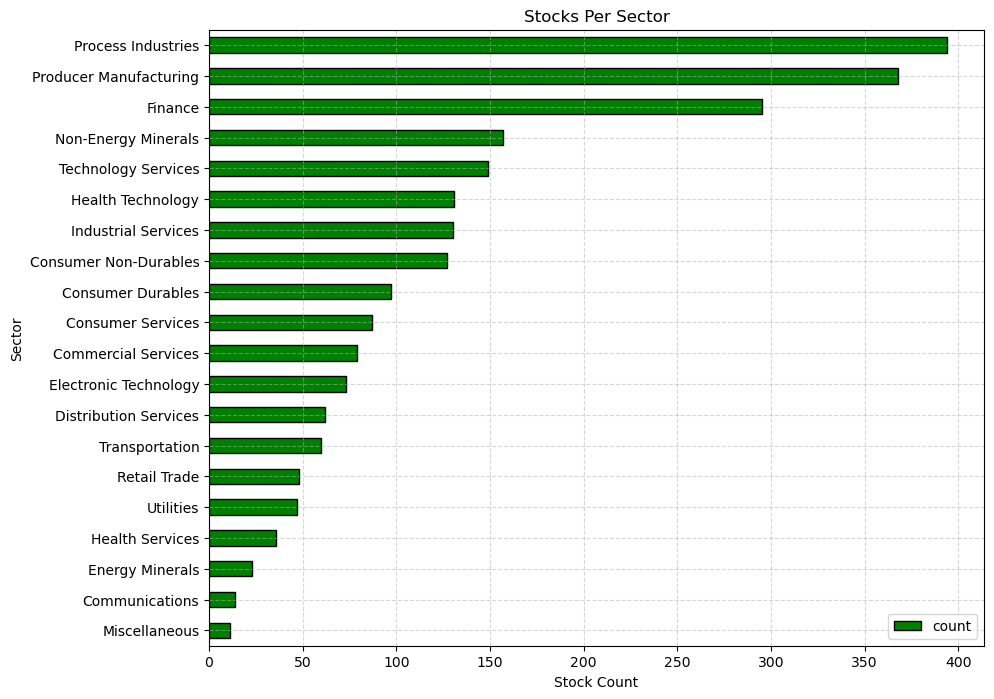

In [14]:
# Stocks Per Sector Analysis 
Num_Stocks=df['Sector'].value_counts().sort_values()

plt.figure(figsize=(10,8))
Num_Stocks.plot(kind="barh",color='green',edgecolor='black')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.title('Stocks Per Sector')
plt.xlabel('Stock Count')
plt.legend()

# Insight Found: There are more companies in the Process Industries followed by Producer Manufacturing 

Text(0, 0.5, '')

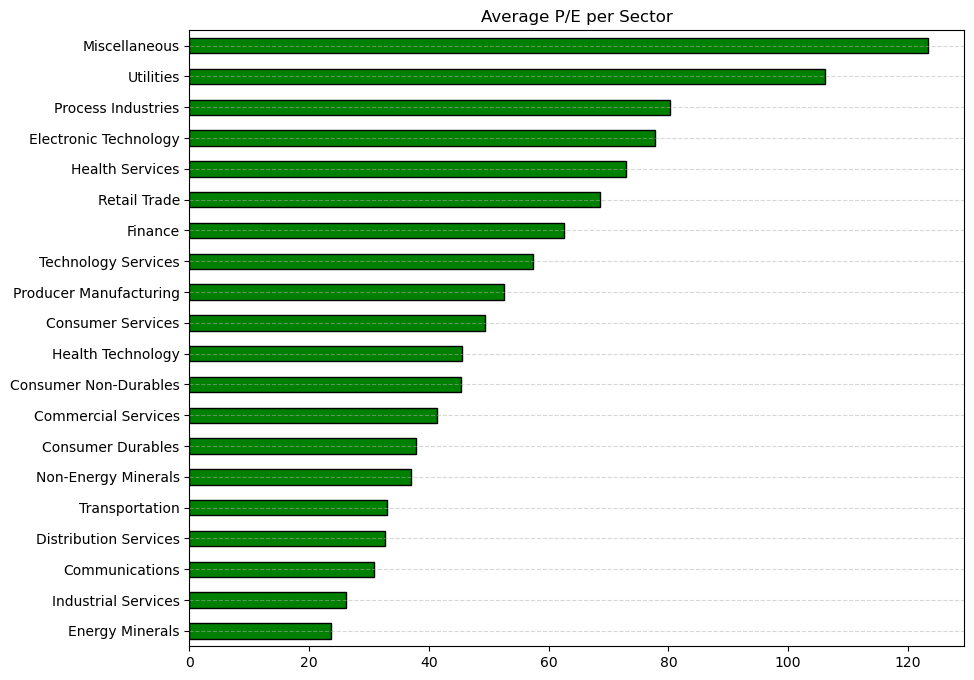

In [15]:
# Average P/E per Sector Analysis
Sector_pe= df.groupby('Sector')['P/E'].mean().sort_values()
plt.figure(figsize=(10,8))
Sector_pe.plot(kind='barh',color='Green',edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Average P/E per Sector')
plt.ylabel('')

# Insight Found: There is high P/E Ratio in the Utilities Sector followed by Process Industries 

Text(0.5, 0, 'EPS YOY')

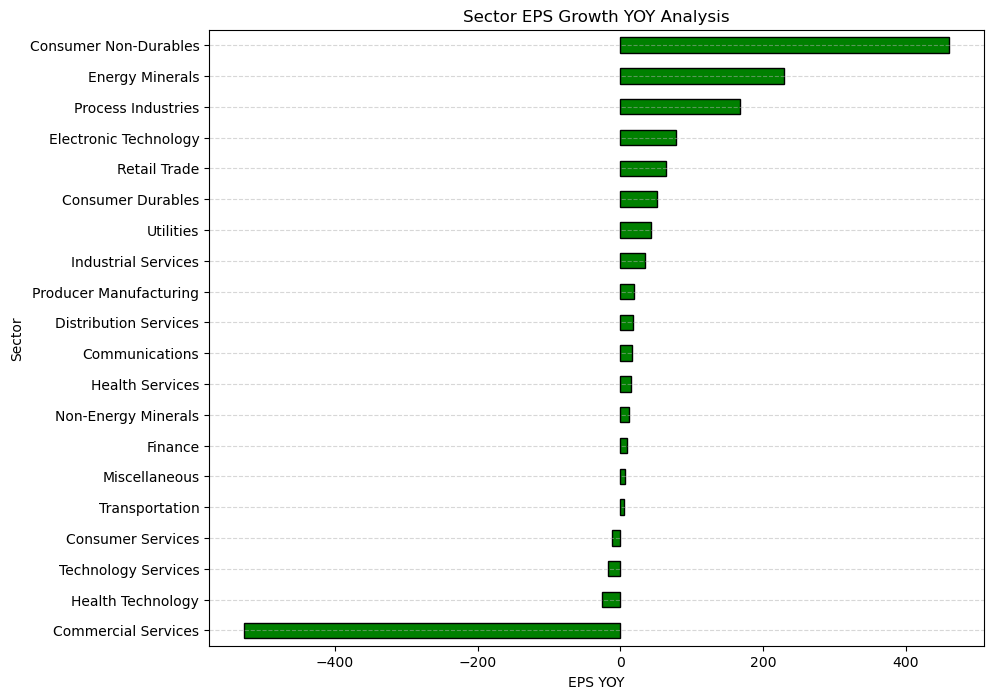

In [16]:
# Sector-wise EPS Growth YoY Analysis
Sector_EPS=df.groupby('Sector')['EPS Growth YoY'].mean().sort_values()

plt.figure(figsize=(10,8))
Sector_EPS.plot(kind='barh',color= 'Green',edgecolor='Black')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Sector EPS Growth YOY Analysis')
plt.xlabel('EPS YOY')

# Insight Found: We have more EPS Growth YoY in THE Consumer Non Durables Sector followed by Energy Minerals 

# Correlation & Relationship Analysis (EDA)

<Axes: >

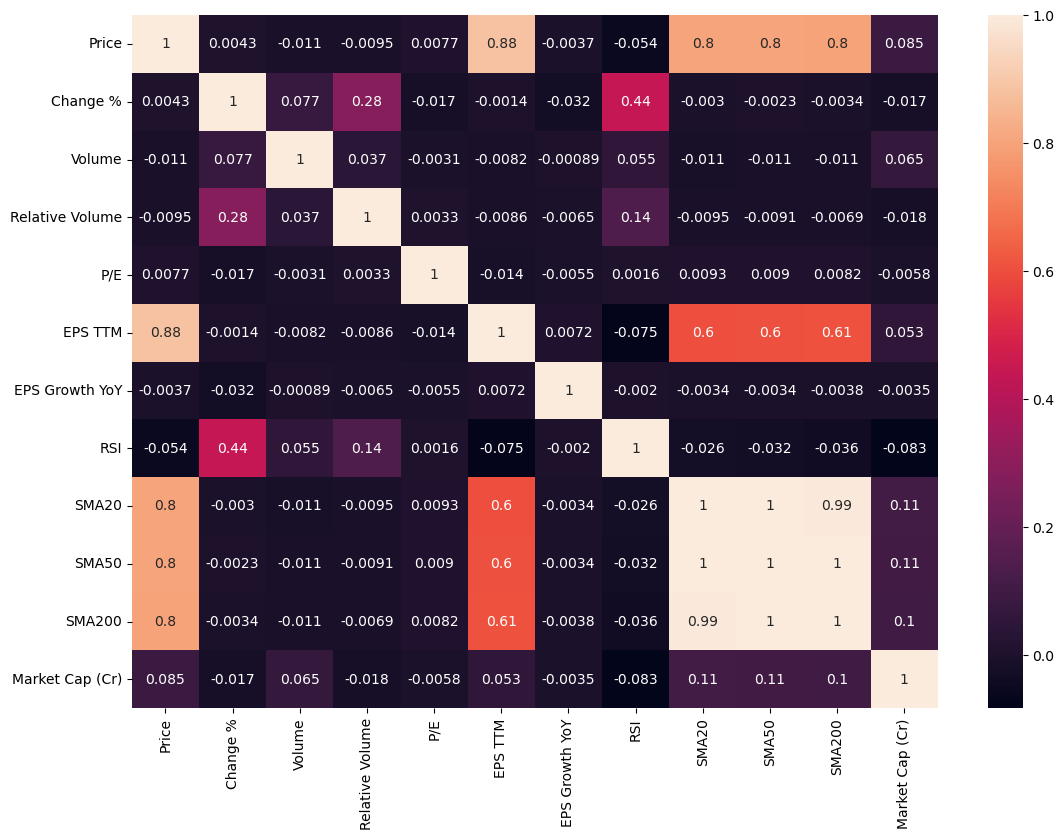

In [17]:
# Correltion Heat Map 
num= df.select_dtypes(include=['float','int'])
num.corr()
plt.figure(figsize=(13,9))
sns.heatmap(num.corr(),annot=True)

# Insight Found: There is a High correlation between Price and SMA 20,50,200 rest all have weak correlation 

Text(0.5, 1.0, 'P/E vs EPS Growth YoY')

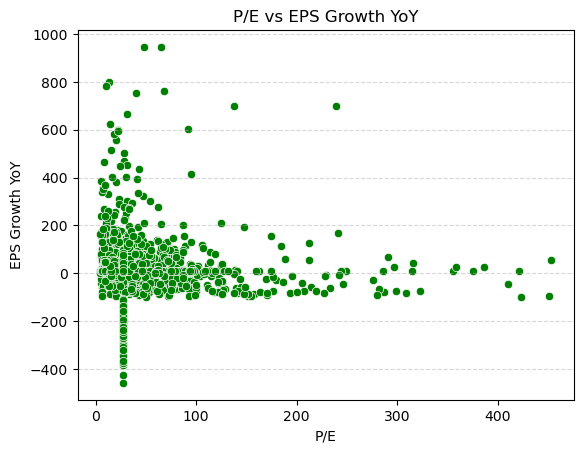

In [18]:
# P/E vs EPS Growth Analysis 
p_low = df["P/E"].quantile(0.01)
p_high = df["P/E"].quantile(0.99)

e_low = df["EPS Growth YoY"].quantile(0.01)
e_high = df["EPS Growth YoY"].quantile(0.99)

filtered_df = df[
    (df["P/E"] >= p_low) &
    (df["P/E"] <= p_high) &
    (df["EPS Growth YoY"] >= e_low) &
    (df["EPS Growth YoY"] <= e_high)
]


sns.scatterplot(x='P/E',y='EPS Growth YoY',data=filtered_df,color='green')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('P/E vs EPS Growth YoY')

# Insight Found: Low to moderate P/E Ratios stocks show highly scattered EPS Growth 

Text(0.5, 1.0, 'RSI vs CHANGE % Analysis')

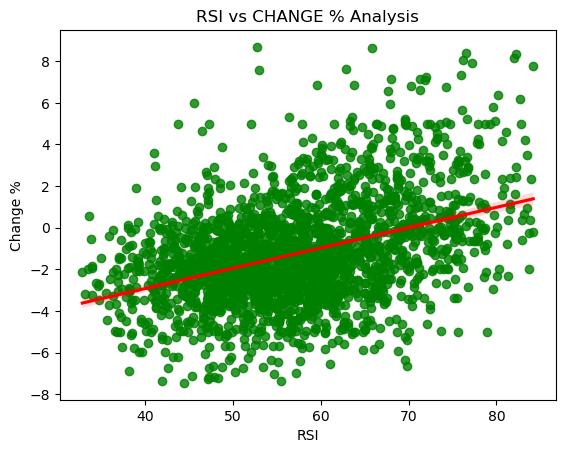

In [19]:
# RSI vs CHANGE % Analysis
c_low=df["Change %"].quantile(0.01)
c_high=df["Change %"].quantile(0.99)

r_low=df['RSI'].quantile(0.01)
r_high=df['RSI'].quantile(0.99)

filtered_df1= df[
    (df["Change %"] >= c_low) &
    (df['Change %'] <= c_high) & 
    (df['RSI']>= r_low) & 
    (df['RSI']<= r_high)
]

sns.regplot(
    x="RSI",
    y="Change %",
    data=filtered_df1,
    line_kws={"color":"red"},
    color='green'
)

plt.title('RSI vs CHANGE % Analysis')

# Insight Found: Stocks with higher RSI generally tend to show more positive price movement

# Outlier Analysis (EDA)

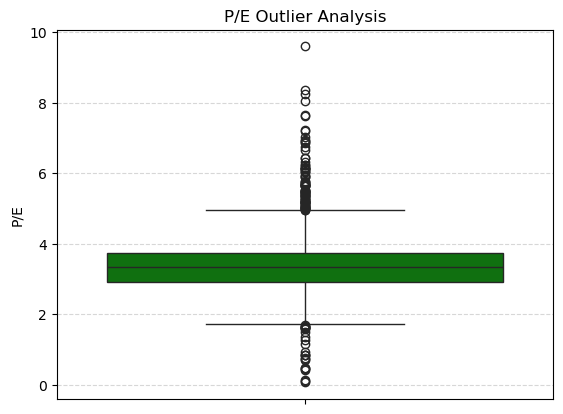

In [20]:
sns.boxplot(np.log1p(df['P/E']),color='green')

plt.title('P/E Outlier Analysis')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Insight Found: Most stocks have a moderate P/E Ratio while some stocks have outliers which can be due to speculative stocks,overvalues stocks 

# Performance Analysis (EDA)

Text(0.5, 1.0, 'TOP 10 Companies by EPS Growth ')

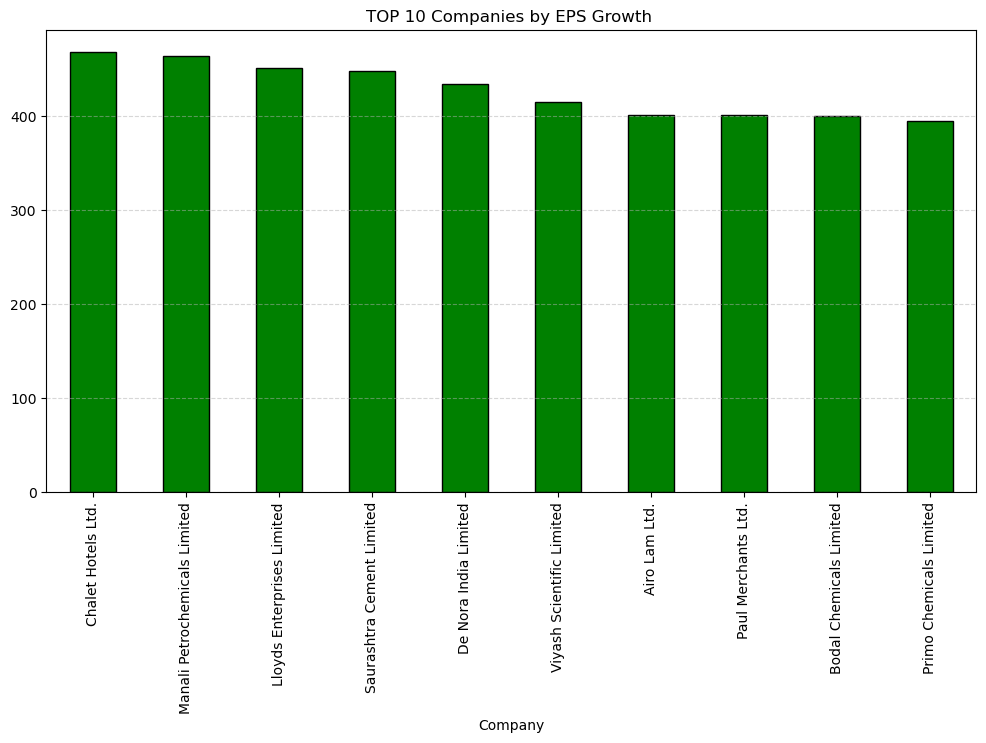

In [21]:
# Removing Outliers
filtered_growth = df[
    (df["EPS Growth YoY"] > -200) &
    (df["EPS Growth YoY"] < 500)
]

# Performing Calculations
s_eps = (
    filtered_growth
    .groupby('Company')['EPS Growth YoY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plotting Graph 
plt.figure(figsize=(12,6))

s_eps.plot(kind='bar',color='green',edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('TOP 10 Companies by EPS Growth ')

# Insight Found : We found that the Highest EPS Growth is 400+ followed by Manali Petrochemicals Ltd.

# Classification Model Predicting Bullish vs Bearish Stocks

In [22]:
ml_df=df.copy() # Copying original DataSet 

# Considering major Change % and removing minor Change %
ml_df = ml_df[ 
    (ml_df["Change %"] > 1) |
    (ml_df["Change %"] < -1)
]

# Creating Target Feature using Condition
ml_df["Target"] = (
    ml_df["Change %"] > 1
).astype(int)

# Limiting our Data Range so that outlier dont dominate
ml_df["P/E"] = ml_df["P/E"].clip(0, 500)
ml_df["EPS Growth YoY"] = ml_df["EPS Growth YoY"].clip(-200, 500)

# Using Log to make the data balanced so that outlier dont dominate
ml_df["Log_Volume"] = np.log1p(ml_df["Volume"])

ml_df["Log_MarketCap"] = np.log1p(
    ml_df["Market Cap (Cr)"])

ml_df["Log_PE"] = np.log1p(
    ml_df["P/E"])


# Feature Engineering

# Price Vs Moving Avg 
ml_df["Price_vs_SMA20"] = (
    ml_df["Price"] - ml_df["SMA20"])

ml_df["Price_vs_SMA50"] = (
    ml_df["Price"] - ml_df["SMA50"])

# Trend strength
ml_df["SMA20_50_Gap"] = (
    ml_df["SMA20"] - ml_df["SMA50"])

# Volume spike indicator
ml_df["Volume_Spike"] = (
    ml_df["Volume"] /
    (ml_df["Relative Volume"] + 1))

# One hot Encoding (Turing Sector into numeric Data)
sector_encoded = pd.get_dummies(
    ml_df["Sector"],
    prefix="Sector",
    drop_first=True)

# Defining Features (Selecting Input Features)
features = [
    "Log_PE",
    "EPS TTM",
    "EPS Growth YoY",
    "RSI",
    "Log_Volume",
    "Relative Volume",
    "SMA20",
    "SMA50",
    "SMA200",
    "Log_MarketCap",
    "Price_vs_SMA20",
    "Price_vs_SMA50",
    "SMA20_50_Gap",
    "Volume_Spike"
]


X = ml_df[features] # Defining x variable
X = pd.concat([X, sector_encoded], axis=1) # Adding Sector Column to x Variable

y = ml_df["Target"] # Defining y Variable

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# Storing SMOTE Function 
smote = SMOTE(random_state=42)

# Training SMOTE Data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# ML Modeling (Random Forest)
model = RandomForestClassifier(
n_estimators=300,
max_depth=10,
min_samples_split=5,
random_state=42
)

# Training the Model
model.fit(X_train_smote,y_train_smote)
y_pred = model.predict(X_test) 

# Model Accuracy - 79%
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report 
Classification_Report=classification_report(y_test, y_pred)
print("\nClassification Report:",Classification_Report)

# Model Precicted 83% Accuracy in predicting Bullish and Bearish Stocks and successfully capturing market momentum patterns 


Accuracy: 0.8342541436464088

Classification Report:               precision    recall  f1-score   support

           0       0.92      0.86      0.89       283
           1       0.60      0.73      0.66        79

    accuracy                           0.83       362
   macro avg       0.76      0.80      0.77       362
weighted avg       0.85      0.83      0.84       362

